In [3]:
import pandas as pd
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import time
import asyncio
import httpx
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None
from scipy import stats
import numpy as np


In [4]:
df = pd.read_csv('comprehensive_non_apartment_sales.csv')

df_lej = pd.read_csv('comprehensive_apartment_sales.csv')

df_lej['btype'] = 'Ejerlejlighed'

df = pd.concat([df, df_lej], ignore_index=True)
print(df.head())
print(df.shape)

if 'dato_x' in df.columns:
    df['dato'] = df['dato_x']
    df.drop(columns=['dato_x'], inplace=True)


if all(col in df.columns for col in ['samlet_koebesum', 'kontant_koebesum', 'købesum']):
    
    for col in ['købesum', 'samlet_koebesum', 'kontant_koebesum']:
        low_count = (df[col] < 10000).sum()
        nan_count = df[col].isna().sum()
    
    problematic_kobesum = (df['købesum'] < 100000) | df['købesum'].isna()
    good_samlet = (df['samlet_koebesum'] >= 100000) & df['samlet_koebesum'].notna()
    
    samlet_fixes = problematic_kobesum & good_samlet
    df.loc[samlet_fixes, 'købesum'] = df.loc[samlet_fixes, 'samlet_koebesum']


    still_problematic = (df['købesum'] < 100000) | df['købesum'].isna()
    good_kontant = (df['kontant_koebesum'] >= 100000) & df['kontant_koebesum'].notna()

    kontant_fixes = still_problematic & good_kontant
    df.loc[kontant_fixes, 'købesum'] = df.loc[kontant_fixes, 'kontant_koebesum']
    
    
    
df.drop(columns=['samlet_koebesum', 'kontant_koebesum', 'loesoeresum', 'salgstype', 'status'], inplace=True)
print (len(df))



   bfe_nummer  købesum  samlet_koebesum  kontant_koebesum  loesoeresum  \
0     1300001  1345335          1345335               NaN          NaN   
1     1300001  1345335          1345335               NaN          NaN   
2     1300001  1525000          1525000               NaN          NaN   
3     1300001  1525000          1525000               NaN          NaN   
4     1300001  1525000          1525000               NaN          NaN   

                      dato_x  sale_sequence  total_sales  is_most_recent  \
0  2003-10-31 23:00:00+00:00              1            6           False   
1  2003-10-31 23:00:00+00:00              2            6           False   
2  2004-06-30 22:00:00+00:00              3            6           False   
3  2004-06-30 22:10:00+00:00              4            6           False   
4  2004-06-30 22:20:00+00:00              5            6           False   

   prev_købesum  price_change  price_change_pct             prev_sale_date  \
0           NaN     

In [3]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")



Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 161


In [23]:

lowest_prices = df.nsmallest(10, 'købesum')
print(lowest_prices[[ 'købesum', 'm2', 'bfe_nummer']])

        købesum     m2  bfe_nummer
11324         1  206.0     1341764
28593         1  166.0     1800261
146784        1  150.0     2120969
245801        1  162.0     2209280
361876        1   97.0     2309788
361881        1  104.0     2309789
361887        1   77.0     2309790
361893        1   81.0     2309791
361897        1  119.0     2309792
361902        1   73.0     2309793


In [5]:
    
df = df.drop_duplicates(subset=['bfe_nummer', 'dato'], keep='first')
print (len(df))

2805351


In [6]:

df['dato'] = pd.to_datetime(df['dato'])

old_dates_mask = df['dato'] < '1992-01-01'
old_dates_data = df[old_dates_mask]

df = df[df['dato'] >= '1992-01-01']
print (len(df))


2554923


In [4]:
initial_count = len(df)

def remove_missing_essential_data(df):
    """Remove rows with missing values in essential columns"""
    
    # Check basic columns
    df = df.dropna(subset=['m2', 'købesum', 'btype','dato', 'by', 'postnummer', 'område'])
    
    # Check for område - could be direct column or one-hot encoded
    if 'område' in df.columns:
        df = df.dropna(subset=['område'])
    else:
        # Handle one-hot encoded områdes - must have at least one area value
        area_cols = [col for col in df.columns if col.startswith('område_')]
        if area_cols:
            # Sum across all area columns - if all are NaN or 0, the sum will be 0
            df = df[df[area_cols].sum(axis=1) > 0]

    
    return df

# Apply the function
df_clean = remove_missing_essential_data(df)
removed_count = initial_count - len(df_clean)

print(f"Removed {removed_count} rows with missing essential data")
print(f"Remaining rows: {len(df_clean)}")

Removed 0 rows with missing essential data
Remaining rows: 2732642


In [15]:
df.dtypes

bfe_nummer                             int64
købesum                                int64
sale_sequence                          int64
total_sales                            int64
is_most_recent                          bool
prev_købesum                         float64
price_change                         float64
price_change_pct                     float64
prev_sale_date                        object
years_since_last_sale                float64
Købesum                                int64
Vær.                                   int64
Byggeår                                int64
dato_y                                object
stype                                 object
m2                                   float64
btype                                 object
addresse                              object
postnummer                             int64
by                                    object
område                                object
region                                object
full_addre

In [7]:

df['pris_pr_m2'] = df['købesum'] / df['m2']
df['year'] = pd.to_datetime(df['dato']).dt.year

# --- Create 3-Year Buckets ---
min_year = df['year'].min()
max_year = df['year'].max()
bins = range(min_year, max_year + 4, 3) # Create bins of 3 years
labels = [f'{i}-{i+2}' for i in range(min_year, max_year + 1, 3)]
df['year_bucket'] = pd.cut(df['year'], bins=bins, labels=labels, right=False)


Q1 = df.groupby(['postnummer', 'year_bucket'])['pris_pr_m2'].transform('quantile', 0.25)
Q3 = df.groupby(['postnummer', 'year_bucket'])['pris_pr_m2'].transform('quantile', 0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1 * IQR
upper_bound = Q3 + 1 * IQR

outlier_mask = (df['pris_pr_m2'] < lower_bound) | (df['pris_pr_m2'] > upper_bound)
outliers = df[outlier_mask]
df_no_outliers = df[~outlier_mask]

print(f"Original dataframe shape: {df.shape}")
print(f"Number of outliers detected: {len(outliers)}")
print(f"Dataframe shape after removing outliers: {df_no_outliers.shape}")


/var/folders/qr/zdl1jn496pg73658gxs99sxh0000gn/T/ipykernel_93575/1949130498.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Q1 = df.groupby(['postnummer', 'year_bucket'])['pris_pr_m2'].transform('quantile', 0.25)
/var/folders/qr/zdl1jn496pg73658gxs99sxh0000gn/T/ipykernel_93575/1949130498.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Q3 = df.groupby(['postnummer', 'year_bucket'])['pris_pr_m2'].transform('quantile', 0.75)


Original dataframe shape: (2554923, 29)
Number of outliers detected: 154111
Dataframe shape after removing outliers: (2400812, 29)


In [20]:
df = df_no_outliers 

Removed 39011 suspicious records
Remaining records: 2388168


In [18]:
df.head()

,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,year,year_bucket,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_5_neighbors_pris,mean_of_5_samebtype_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,100000,4296181,NaN,3,133.0,Ejerlejlighed,2600,Glostrup,12.374093,55.667897,2018,2016-2018,29386.313270,38239.169226,NaN,NaN,NaN,9832,NaN,5.0,31242.024308,5.0,31242.024308,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,4.155189e+06,4.155189e+06,3.908380e+06,NaN,5.085810e+06,NaN
2018-10-14 22:00:00+00:00,100030,2048000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,2016-2018,17365.689256,18652.015356,NaN,NaN,NaN,9782,NaN,5.0,22196.846840,5.0,22196.846840,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,2.108700e+06,2.108700e+06,1.649740e+06,NaN,1.771941e+06,NaN
2019-09-12 22:00:00+00:00,100030,2025000,2048000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2019,2019-2021,17177.814239,18063.425951,21557.894737,17365.689256,18652.015356,10115,333.0,5.0,22236.670062,5.0,22236.670062,4192.205481,24.140738,2905.879381,15.579439,0,0,0,0,0,1,0,2.112484e+06,2.112484e+06,1.631892e+06,2.025843e+06,1.716025e+06,1.983373e+06
2020-09-29 22:00:00+00:00,100030,2198000,2025000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2020,2019-2021,16949.507296,17645.644387,21315.789474,17177.814239,18063.425951,10498,383.0,2.0,26008.533090,2.0,26008.533090,4137.975235,24.089067,3252.363522,18.005242,0,0,0,0,0,1,0,2.470811e+06,2.470811e+06,1.610203e+06,1.998086e+06,1.676336e+06,1.978165e+06
2018-09-30 22:00:00+00:00,100031,2798000,NaN,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,2018,2016-2018,17787.806166,18425.000711,NaN,NaN,NaN,9768,NaN,3.0,22027.663051,3.0,22027.663051,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,2.929679e+06,2.929679e+06,2.365778e+06,NaN,2.450525e+06,NaN


In [8]:
# Filter for postnummer 2960 and date range
df_filtered = df_no_outliers[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 144


/var/folders/qr/zdl1jn496pg73658gxs99sxh0000gn/T/ipykernel_93575/803764930.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df_no_outliers[


In [21]:
#df['dato'] = pd.to_datetime(df['dato']) # im making date the index
df = df.sort_values('dato')
df = df.set_index('dato')

In [10]:
print(df.shape)

(2471149, 28)


In [22]:
#here i get the rolling mean for price per square meter for different time windows and geographical areas

df = df.sort_index()

levels = ['postnummer', ['postnummer', 'btype']]  # All properties in postnummer, then by postnummer + btype
time_windows = ['365D']

for level in levels:
    for window in time_windows:
        if isinstance(level, list):
            level_name = '_'.join(level)
            new_col_name = f'pris_pr_m2_mean_{window}_{level_name}'
        else:
            level_name = level
            new_col_name = f'pris_pr_m2_mean_{window}_{level_name}'
        
        #calculates rolling mean for price per square meter
        df[new_col_name] = df.groupby(level)['pris_pr_m2'].transform(
            lambda x: x.rolling(window, min_periods=1, closed='left').mean()
        ) #the first values will be nan, so we fill them with 0 we discard later
        print(f"Calculated {new_col_name}")

Calculated pris_pr_m2_mean_365D_postnummer
Calculated pris_pr_m2_mean_365D_postnummer_btype


In [23]:
df.shape

(2400812, 30)

In [ ]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

In [20]:
df.to_csv("afterlagtesttest.csv")

In [47]:
dftry = pd.read_csv("afterlagtesttest.csv")

In [55]:
dftry['dato'] = pd.to_datetime(dftry['dato'], errors='coerce', utc=True)

dftry.sort_values([ 'dato'], inplace=True)

dftry.tail(10)


,dato,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct
2129338,2025-06-26 22:00:00+00:00,7887525,310000,2,2,True,330000.0,-20000.0,-6.060606,1998-06-08 22:00:00+00:00,27.049966,330000,3,1800,17-05-1998,Alm. Salg,91.0,Villa,"Fårdalvej 1, Velds",8830,Tjele,Øst- og Midtjylland,Jylland,"Fårdalvej 1, Velds, 8830 Tjele",9.613487,56.473729,3406.593407,11143.452845,8411.297563,3626.373626,4637.916504,3950.560977,12229,9880.0,2.0,45027.173913,40027.173913,1.0,5000.000000,0.000000,-1011.542878,-21.810287,-324.187351,-8.206109
538419,2025-06-26 22:00:00+00:00,2073565,9350000,2,2,True,4575000.0,4775000.0,104.371585,2015-01-07 23:00:00+00:00,10.464066,4575000,5,1959,07-12-2014,Alm. Salg,153.0,Villa,Furesøkrogen 2,2830,Virum,"Hovedstaden, København",Sjælland,"Furesøkrogen 2, 2830 Virum",12.442225,55.795407,61111.111111,50277.352307,57484.396059,29901.960784,27208.327163,28595.671855,12229,3822.0,2.0,55161.505162,33.300033,2.0,55161.505162,33.300033,2693.633622,9.900034,1306.288929,4.568135
529991,2025-06-26 22:00:00+00:00,2062792,5395000,2,2,True,1148000.0,4247000.0,369.947735,2000-01-31 23:00:00+00:00,25.399042,1148000,2,1938,19-02-1998,Alm. Salg,78.0,Rækkehus,Birkevang 36,2830,Virum,"Hovedstaden, København",Sjælland,"Birkevang 36, 2830 Virum",12.484823,55.794793,69166.666667,50277.352307,54373.856655,14717.948718,11704.668517,12743.263202,12229,9277.0,2.0,60833.333333,2166.666667,2.0,60833.333333,2166.666667,3013.280201,25.744259,1974.685516,15.495917
1527795,2025-06-26 22:00:00+00:00,4364635,1850000,4,4,True,1385000.0,465000.0,33.574007,2006-03-27 22:00:00+00:00,19.249829,1385000,4,1977,14-03-2006,Alm. Salg,93.0,Rækkehus,Prangerager 82,7120,Vejle Øst,Sydjylland,Jylland,"Prangerager 82, 7120 Vejle Øst",9.610921,55.721944,19892.473118,24296.512221,22850.210752,14892.473118,9330.286611,12012.632071,12229,7031.0,NaN,NaN,NaN,NaN,NaN,NaN,5562.186507,59.614316,2879.841047,23.973439
2126879,2025-06-26 22:00:00+00:00,7856128,6060000,3,3,True,3700000.0,2360000.0,63.783784,2021-06-07 22:00:00+00:00,4.052019,3700000,7,1998,18-04-2021,Alm. Salg,207.0,Villa,Fugldalen 16,8680,Ry,Øst- og Midtjylland,Jylland,"Fugldalen 16, 8680 Ry",9.777334,56.079940,29275.362319,25011.352118,24789.062283,17874.396135,21444.623954,20624.943956,12229,1480.0,NaN,NaN,NaN,NaN,NaN,NaN,-3570.227819,-16.648591,-2750.547821,-13.336026
520114,2025-06-26 22:00:00+00:00,2051307,4900000,7,7,True,2795000.0,2105000.0,75.313059,2008-03-24 23:00:00+00:00,17.253936,2795000,4,1975,09-03-2008,Alm. Salg,106.0,Villa,Egtvedvej 31,2770,Kastrup,"Hovedstaden, København",Sjælland,"Egtvedvej 31, 2770 Kastrup",12.579001,55.609439,46226.415094,39241.021686,39343.986903,26367.924528,18422.081254,17838.179641,12229,6302.0,3.0,52727.748546,6059.688311,3.0,52727.748546,6059.688311,7945.843275,43.132169,8529.744887,47.817351
2313310,2025-06-26 22:00:00+00:00,9704233,2398000,3,3,True,530000.0,1868000.0,352.452830,2005-02-24 23:00:00+00:00,20.331280,530000,4,1926,14-08-2004,Alm. Salg,175.0,Villa,Stouby Kirkevej 11,7140,Stouby,Sydjylland,Jylland,"Stouby Kirkevej 11, 7140 Stouby",9.784636,55.721145,13702.857143,11110.019726,10153.373761,3028.571429,5994.418204,5418.834924,12229,7426.0,1.0,7838.283828,0.000000,1.0,7838.283828,0.000000,-2965.846776,-49.476808,-2390.263495,-44.110284

In [ ]:


df['pris_pr_m2_prev'] = df['prev_købesum'] / df['m2']  

df = df.reset_index()

df['dato'] = pd.to_datetime(df['dato'], errors='coerce', utc=True)

df.sort_values(['bfe_nummer', 'dato'], inplace=True)

df['prev_sale_date'] = df.groupby('bfe_nummer')['dato'].shift(1)
df['prev_købesum'] = df.groupby('bfe_nummer')['købesum'].shift(1)
df['pris_pr_m2_prev'] = df.groupby('bfe_nummer')['pris_pr_m2'].shift(1)
df['pris_pr_m2_mean_postummer_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer'].shift(1)
df['pris_pr_m2_mean_postnummer_btype_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer_btype'].shift(1)

dataset_start_date = df['dato'].min()

df['days_since_dataset_start'] = (df['dato'] - dataset_start_date).dt.days


#df['price_change'] = df['købesum'] - df['prev_købesum']
#df['price_change_pct'] = (df['price_change'] / df['prev_købesum']) * 100

df.set_index('dato', inplace=True)

df['days_since_last_sale'] = (df.index - df['prev_sale_date']).dt.days


In [59]:
df.head(10)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2_temp,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,100000,4296181,1,1,True,NaN,NaN,NaN,NaT,NaN,4296181,3,2019,11-12-2017,Alm. Salg,133.0,Ejerlejlighed,"Stadionvej 86, 3. 1",2600,Glostrup,"Hovedstaden, København",Sjælland,"Stadionvej 86, 3. 1, 2600 Glostrup",12.374093,55.667897,32302.112782,32302.112782,NaN,28562.422858,26461.939729,25434.196252,28562.422858,26461.939729,25434.196252,36088.301542,34966.830985,34493.509286,32972.455435,31952.834894,31551.749696,NaN,NaN,NaN
2018-10-14 22:00:00+00:00,100030,2048000,1,3,False,NaN,NaN,NaN,NaT,NaN,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,21557.894737,21557.894737,NaN,17779.805432,17045.945373,17766.585423,17779.805432,17045.945373,17766.585423,14957.363891,14474.750297,14736.436189,21486.789671,21880.027114,22055.663780,NaN,NaN,NaN
2019-09-12 22:00:00+00:00,100030,2025000,2,3,False,2048000.0,-23000.0,-1.123047,2018-10-14 22:00:00+00:00,0.911704,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,21315.789474,21315.789474,21557.894737,17866.325322,17615.640232,17460.604202,17866.325322,17615.640232,17460.604202,16078.608639,16408.236912,15874.301095,23522.688118,23859.629895,22778.456746,17766.585423,17766.585423,333.0
2020-09-29 22:00:00+00:00,100030,2198000,3,3,True,2025000.0,173000.0,8.543210,2019-09-12 22:00:00+00:00,1.048597,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,23136.842105,23136.842105,21315.789474,18702.905040,17093.932735,17123.704883,18702.905040,17093.932735,17123.704883,16953.712985,16070.472866,15390.167131,23648.046235,22985.000398,22480.700392,17460.604202,17460.604202,383.0
2018-09-30 22:00:00+00:00,100031,2798000,1,2,False,NaN,NaN,NaN,NaT,NaN,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,21037.593985,21037.593985,NaN,17272.023346,17032.428974,17534.125740,17272.023346,17032.428974,17534.125740,14665.031372,14550.461378,14800.196460,22667.005074,21985.619463,22212.970611,NaN,NaN,NaN
2019-03-20 23:00:00+00:00,100031,2998000,2,2,True,2798000.0,200000.0,7.147963,2018-09-30 22:00:00+00:00,0.468172,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,22541.353383,22541.353383,21037.593985,17610.104413,17425.131419,17231.986035,17610.104413,17425.131419,17231.986035,14695.700856,15331.632227,15006.996356,19634.945505,21562.769030,21731.016994,17534.125740,17534.125740,171.0
2018-09-20 22:00:00+00:00,100032,2098000,1,1,True,NaN,NaN,NaN,NaT,NaN,2098000,3,1929,20-09-2018,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, 1.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, 1., 6700 Esbjerg",8.446658,55.470418,22084.210526,22084.210526,NaN,16884.291200,17135.272653,17484.471326,16884.291200,17135.272653,17484.471326,13819.185490,1453

In [25]:
def nnfeatures(df: pd.DataFrame, k_values: list, closeness_feature_cols: list, value_col: str, date_col='dato', lookback_days=365):
    #For each property, find nearby properties that sold recently and calculate their mean
    scaler = StandardScaler()
    # i think it is important, unless you live in the middle of the earth
    X_scaled = scaler.fit_transform(df[closeness_feature_cols])
    
    # we need to get more than max k, becouse we will cut many away. 4 is magic number, after further analasys i dont think it matters 
    max_k = max(k_values)
    radius = max_k * 8# increased from earlier version, honstly can be played around with
    nn_model = NearestNeighbors(n_neighbors=radius, metric='euclidean')
    nn_model.fit(X_scaled)
    # Get distances and indices of neighbors for every point
    distances, indices = nn_model.kneighbors(X_scaled)

    all_results = []
    
    all_dates = df.index.values
    all_values = df[value_col].values
    all_btypes = df['btype'].values  
    total_rows = len(df)

    loop_start_time = time.time()

    for i in range(total_rows):
        #for every 50000 rows, print the progress and rate
        if (i + 1) % 50000 == 0:
            elapsed = time.time() - loop_start_time
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            print(f"--- Processed {i + 1} / {total_rows} properties ({rate:.0f} rows/sec) ---")
        #get the rows sales date    
        target_date = all_dates[i]
        target_btype = all_btypes[i]  

        #get the indices of the neighbors
        neighbor_indices = indices[i]
        #get the dates of the neighbors
        neighbor_dates = all_dates[neighbor_indices]
        neighbor_btypes = all_btypes[neighbor_indices]  # Get neighbor building types

        
        #filter the neighbors by the time window, it needs to have happened before to prevent data leakage, but not to much before to avoid old data
        time_window_mask = (neighbor_dates < target_date) & \
(neighbor_dates >= (target_date - pd.Timedelta(days=lookback_days)))
        # the neighbors that get through the time mask 

        valid_neighbor_indices = neighbor_indices[time_window_mask]
        valid_neighbor_btypes = neighbor_btypes[time_window_mask]

         # Filter for same building type
        btype_mask = valid_neighbor_btypes == target_btype
        valid_samebtype_indices = valid_neighbor_indices[btype_mask]
        
        row_stats = {}
        for k in k_values:
            # Get the top k valid neighbors
            final_indices = valid_neighbor_indices[:k]
            
            num_neighbors = len(final_indices)
            #get the stats
            if num_neighbors > 0:
                neighbor_values = all_values[final_indices]
                row_stats[f'num_of_{k}_neighbors'] = num_neighbors
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.mean(neighbor_values)
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.std(neighbor_values)
            else:
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.nan
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.nan

            final_samebtype_indices = valid_samebtype_indices[:k]
            num_samebtype_neighbors = len(final_samebtype_indices)
            
            if num_samebtype_neighbors > 0:
                samebtype_neighbor_values = all_values[final_samebtype_indices]
                row_stats[f'num_of_{k}_samebtype_neighbors'] = num_samebtype_neighbors
                row_stats[f'mean_of_{k}_samebtype_neighbors_{value_col}'] = np.mean(samebtype_neighbor_values)
                row_stats[f'std_of_{k}_samebtype_neighbors_{value_col}'] = np.std(samebtype_neighbor_values)
            else:
                row_stats[f'mean_of_{k}_samebtype_neighbors_{value_col}'] = np.nan
                row_stats[f'std_of_{k}_samebtype_neighbors_{value_col}'] = np.nan    
        
        all_results.append(row_stats)
    
    end_time = time.time()
    print(f"finished in {(end_time - loop_start_time)/60:.2f} minutes")

    return pd.DataFrame(all_results, index=df.index)


k = [5]
coordinates = ['x', 'y'] 
target_col = 'pris_pr_m2'

neighbor_features_df = nnfeatures(
    df=df,
    k_values=k,
    closeness_feature_cols=coordinates,
    value_col=target_col
)
df_final = pd.concat([df, neighbor_features_df], axis=1)



# Compare the property previous price to the market average at that time
df_final['historical_premium_vs_postnummer'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postummer_prev']
df_final['historical_premium_vs_postnummer_pct'] = (df_final['historical_premium_vs_postnummer'] / df_final['pris_pr_m2_mean_postummer_prev']) * 100

df_final['historical_premium_vs_postnummer_btype'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postnummer_btype_prev']
df_final['historical_premium_vs_postnummer_btype_pct'] = (df_final['historical_premium_vs_postnummer_btype'] / df_final['pris_pr_m2_mean_postnummer_btype_prev']) * 100 # we are getting some crazy column names


--- Processed 50000 / 2400812 properties (30381 rows/sec) ---
--- Processed 100000 / 2400812 properties (29882 rows/sec) ---
--- Processed 150000 / 2400812 properties (31008 rows/sec) ---
--- Processed 200000 / 2400812 properties (31219 rows/sec) ---
--- Processed 250000 / 2400812 properties (31023 rows/sec) ---
--- Processed 300000 / 2400812 properties (31089 rows/sec) ---
--- Processed 350000 / 2400812 properties (30821 rows/sec) ---
--- Processed 400000 / 2400812 properties (31086 rows/sec) ---
--- Processed 450000 / 2400812 properties (31191 rows/sec) ---
--- Processed 500000 / 2400812 properties (31559 rows/sec) ---
--- Processed 550000 / 2400812 properties (31801 rows/sec) ---
--- Processed 600000 / 2400812 properties (32074 rows/sec) ---
--- Processed 650000 / 2400812 properties (32211 rows/sec) ---
--- Processed 700000 / 2400812 properties (32377 rows/sec) ---
--- Processed 750000 / 2400812 properties (32424 rows/sec) ---
--- Processed 800000 / 2400812 properties (32567 rows/se

In [28]:
df_final = pd.concat([df_outlier_removed, neighbor_features_df], axis=1)



# Compare the property previous price to the market average at that time
df_final['historical_premium_vs_postnummer'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postummer_prev']
df_final['historical_premium_vs_postnummer_pct'] = (df_final['historical_premium_vs_postnummer'] / df_final['pris_pr_m2_mean_postummer_prev']) * 100

df_final['historical_premium_vs_postnummer_btype'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postnummer_btype_prev']
df_final['historical_premium_vs_postnummer_btype_pct'] = (df_final['historical_premium_vs_postnummer_btype'] / df_final['pris_pr_m2_mean_postnummer_btype_prev']) * 100 # we are getting some crazy column names


In [11]:
df_final.to_csv("with_neighborstesttest.csv")

In [26]:
df=df_final.copy()

In [54]:
dftry= pd.read_csv("with_neighborstesttest.csv")
print(df.shape)

(2400812, 40)


In [115]:
(df['btype'] == 'Ejerlejlighed').sum()

np.int64(423450)

In [29]:
df.shape

(2400812, 45)

In [46]:
df.sample(15) # cool huh. these are the two cool features that i made, mean of the neighbors and mean of the area. they are very similar

,level_0,index,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,std_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,std_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,std_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,std_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1992-09-30 23:00:00+00:00,1346649,15749,4232230,685000,1,1,True,NaN,NaN,NaN,NaT,NaN,2515000,5,1936,21-12-2023,Fam. Salg,224.0,Villa,"Bøgeskovvej 12, Rasborg",8355,Solbjerg,Øst- og Midtjylland,Jylland,"Bøgeskovvej 12, Rasborg, 8355 Solbjerg",10.084424,56.022125,3058.035714,6215.542895,4485.977889,NaN,NaN,NaN,NaN,2.0,4622.390351,289.890351,1.0,4332.500000,0.000000,2.0,4622.390351,289.890351,1.0,4332.500000,0.000000,2.0,4622.390351,289.890351,1.0,4332.500000,0.000000,NaN,NaN,NaN,NaN
2007-12-31 23:00:00+00:00,505852,1124748,2116166,2325000,2,2,True,2325000.0,0.0,0.000000,2007-12-18 23:00:00+00:00,0.035592,4650000,7,1971,20-10-2007,Alm. Salg,225.0,Villa,Skovbuen 49,2605,Brøndby,"Hovedstaden, København",Sjælland,"Skovbuen 49, 2605 Brøndby",12.429315,55.652162,10333.333333,16727.159207,15299.506181,10333.333333,16752.797691,15299.044696,13.0,5.0,17875.283821,7826.564569,5.0,17875.283821,7826.564569,9.0,18507.782950,7660.219582,8.0,18086.880819,8026.170140,9.0,18507.782950,7660.219582,8.0,18086.880819,8026.170140,-6419.464357,-38.318760,-4965.711363,-32.457656
2001-12-09 23:00:00+00:00,1517713,534670,4509417,415000,1,1,True,NaN,NaN,NaN,NaT,NaN,415000,3,1927,28-08-2001,Alm. Salg,126.0,Villa,Åbakkevej 8,7540,Haderup,Sydjylland,Jylland,"Åbakkevej 8, 7540 Haderup",8.995979,56.388067,3293.650794,3542.454837,3243.679652,NaN,NaN,NaN,NaN,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,NaN,NaN,NaN,NaN
2020-02-27 23:00:00+00:00,1896774,1938566,5682967,1275000,4,4,True,918002.0,356998.0,38.888586,2004-12-30 23:00:00+00:00,15.159480,1275000,3,1981,18-02-2020,Alm. Salg,99.0,Rækkehus,Bjolderupvej 23A,6000,Kolding,Sydjylland,Jylland,"Bjolderupvej 23A, 6000 Kolding",9.475835,55.473409,12878.787879,13461.043551,15898.452453,9272.747475,7322.059149,8878.281240,5537.0,5.0,11546.158146,3770.160585,1.0,14141.414141,0.000000,6.0,12627.262936,4205.832878,1.0,14141.414141,0.000000,6.0,12627.262936,4205.832878,1.0,14141.414141,0.000000,1950.688326,26.641253,394.466234,4.443047
2003-10-31 23:10:00+00:00,1055475,706193,3171048,492500,3,4,False,492500.0,0.0,0.000000,2003-10-31 23:00:00+00:00,0.000000,1595000,5,2001,13-11-2023,Alm. Salg,79.0,Fritidshus,"Havbruset 3, Skal Klit",9800,Hjørring,Nordjylland,Jylland,"Havbruset 3, Skal Klit, 9800 Hjørring",9.863443,57.505119,6234.177215,5744.672644,7527.585671,6234.177215,5745.666163,7406.779466,0.0,5.0,9381.655999,2782.870021,5.0,9381.655999,2782.870021,15.0,7112.473175,3744.663602,15.0,7112.473175,3744.663602,19.0,7807.503148,3850.396070,19.0,7807.503148,3850.396070,488.511052,8.502253,-1172.602251,-15.831472
2003-03-31 22:00:00+00:00,2114014,648208,8915981,3925000,2,2,True,NaN,NaN,NaN,NaT,11.750

,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,pris_pr_m2,year,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_5_neighbors_pris,mean_of_5_samebtype_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-12-18 23:00:00+00:00,2116166,2325000,NaN,7,225.0,Villa,2605,Brøndby,12.429315,55.652162,10333.333333,2007,16821.301542,15416.676910,NaN,NaN,NaN,5830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,NaN,NaN,3.784793e+06,NaN,3.468752e+06,NaN
2007-12-31 23:00:00+00:00,2116166,2325000,2325000.0,7,225.0,Villa,2605,Brøndby,12.429315,55.652162,10333.333333,2007,16794.677490,15414.154522,10333.333333,16821.301542,15416.67691,5843,13.0,1.0,10333.333333,1.0,10333.333333,-6487.968208,-38.569954,-5083.343576,-32.973018,0,0,1,0,0,0,0,2325000.0,2325000.0,3.778802e+06,2.321320e+06,3.468185e+06,2.324620e+06


In [27]:
#add one hot enconding to area, sale type, and building type
categorical_cols = ['område']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


In [32]:
#we remove the columns that are not needed for the model
cols_to_drop = [
    'addresse',
    'full_address',
    'region',
    
   
   'dato_y', 'std_of_5_neighbors_pris_pr_m2',
  'is_most_recent', 'sale_sequence', 'price_change', 'price_change_pct',
  'total_sales', 'stype',  'Købesum','prev_sale_date', 'years_since_last_sale' , 'Byggeår', 
  'std_of_5_samebtype_neighbors_pris_pr_m2', 'year_bucket'
    ]
df = df_encoded.drop(columns=cols_to_drop).copy()

In [33]:
df.columns

Index(['bfe_nummer', 'købesum', 'prev_købesum', 'Vær.', 'm2', 'btype',
       'postnummer', 'by', 'x', 'y', 'pris_pr_m2', 'year',
       'pris_pr_m2_mean_365D_postnummer',
       'pris_pr_m2_mean_365D_postnummer_btype', 'pris_pr_m2_prev',
       'pris_pr_m2_mean_postummer_prev',
       'pris_pr_m2_mean_postnummer_btype_prev', 'days_since_dataset_start',
       'days_since_last_sale', 'num_of_5_neighbors',
       'mean_of_5_neighbors_pris_pr_m2', 'num_of_5_samebtype_neighbors',
       'mean_of_5_samebtype_neighbors_pris_pr_m2',
       'historical_premium_vs_postnummer',
       'historical_premium_vs_postnummer_pct',
       'historical_premium_vs_postnummer_btype',
       'historical_premium_vs_postnummer_btype_pct', 'område_Bornholm',
       'område_Fyn og øer', 'område_Hovedstaden, København',
       'område_Nordjylland', 'område_Nordsjælland', 'område_Sydjylland',
       'område_Øst- og Midtjylland'],
      dtype='object')

In [17]:
df.head(10)

,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,year,year_bucket,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,100000,4296181,NaN,3,133.0,Ejerlejlighed,2600,Glostrup,12.374093,55.667897,2018,2016-2018,24308.315285,25337.543213,NaN,NaN,NaN,9832,NaN,5.0,31034.010604,5.0,31034.010604,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0
2018-10-14 22:00:00+00:00,100030,2048000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,2016-2018,15356.294017,15990.237060,NaN,NaN,NaN,9782,NaN,5.0,22132.609912,5.0,22132.609912,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-09-12 22:00:00+00:00,100030,2025000,2048000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2019,2019-2021,16071.459421,16683.092119,21557.894737,15356.294017,15990.237060,10115,333.0,5.0,22236.670062,5.0,22236.670062,6201.600719,40.384749,5567.657677,34.819107,0,0,0,0,0,1,0
2020-09-29 22:00:00+00:00,100030,2198000,2025000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2020,2019-2021,16268.595453,16529.897940,21315.789474,16071.459421,16683.092119,10498,383.0,1.0,22828.947368,1.0,22828.947368,5244.330053,32.631324,4632.697354,27.768817,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,100031,2798000,NaN,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,2018,2016-2018,15123.679944,15758.730672,NaN,NaN,NaN,9768,NaN,3.0,22027.663051,3.0,22027.663051,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-03-20 23:00:00+00:00,100031,2998000,2798000.0,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,2019,2019-2021,15627.567228,16144.808917,21037.593985,15123.679944,15758.730672,9940,171.0,5.0,20967.943927,5.0,20967.943927,5913.914041,39.103671,5278.863313,33.498024,0,0,0,0,0,1,0
2018-09-20 22:00:00+00:00,100032,2098000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,2016-2018,15078.579101,15706.212591,NaN,NaN,NaN,9758,NaN,1.0,15674.418605,1.0,15674.418605,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,100033,1698000,NaN,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,2016-2018,15123.679944,15758.730672,NaN,NaN,NaN,9768,NaN,4.0,20439.351939,4.0,20439.351939,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-12-15 23:00:00+00:00,100033,1735000,1698000.0,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2019,2019-2021,16192.393027,16467.296172,22342.105263,15123.679944,15758.730672,10210,441.0,2.0,21928.571429,2.0,21928.571429,7218.425319,47.729292,6583.374592,41.776046,0,0,0,0,0,1,0


In [116]:
df.to_csv("cleaned_data_harshtesttest.csv")

In [117]:
df= pd.read_csv("cleaned_data_harshtesttest.csv")


In [94]:
df.head(10)

,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,btype,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_pris
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-14 22:00:00+00:00,1829160,2048000,NaN,NaN,NaN,3,95.0,Ejerlejlighed,16481.421557,17494.808138,NaN,NaN,NaN,NaN,5.0,22086.202226,5.0,22086.202226,12.0,19208.539882,9.0,20847.804746,12.0,19208.539882,9.0,20847.804746,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.824811e+06,1.565735e+06,NaN,1.662007e+06,NaN,2.098189e+06
2019-09-12 22:00:00+00:00,1902346,2025000,2048000.0,-23000.0,-1.123047,3,95.0,Ejerlejlighed,16683.899327,17396.784734,21557.894737,16481.421557,17494.808138,333.0,5.0,22236.670062,5.0,22236.670062,15.0,21917.402648,15.0,21917.402648,23.0,23279.108919,21.0,23335.193827,5076.473180,30.801185,4063.086598,23.224528,0,0,0,0,0,1,0,2.211515e+06,1.584970e+06,2.073160e+06,1.652695e+06,2.036525e+06,2.112484e+06
2020-09-29 22:00:00+00:00,1993512,2198000,2025000.0,173000.0,8.543210,3,95.0,Ejerlejlighed,16288.591284,16916.784785,21315.789474,16683.899327,17396.784734,383.0,5.0,25238.517021,5.0,23364.274597,9.0,20219.341680,7.0,20540.808386,9.0,20219.341680,7.0,20540.808386,4631.890147,27.762635,3919.004739,22.527178,0,0,0,0,0,1,0,1.920837e+06,1.547416e+06,1.977020e+06,1.607095e+06,1.969128e+06,2.397659e+06
2018-09-30 22:00:00+00:00,1825373,2798000,NaN,NaN,NaN,4,133.0,Ejerlejlighed,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,2.402298e+06,2.151171e+06,NaN,2.294938e+06,NaN,2.424703e+06
2019-03-20 23:00:00+00:00,1861242,2998000,2798000.0,200000.0,7.147963,4,133.0,Ejerlejlighed,16457.431420,17065.133989,21037.593985,16174.217672,17255.170765,171.0,5.0,20984.115970,5.0,20984.115970,12.0,20517.288827,11.0,20804.380408,12.0,20517.288827,11.0,20804.380408,4863.376313,30.068696,3782.423220,21.920520,0,0,0,0,0,1,0,2.728799e+06,2.188838e+06,2.846994e+06,2.269663e+06,2.767185e+06,2.790887e+06
2018-09-20 22:00:00+00:00,1823205,2098000,NaN,NaN,NaN,3,95.0,Ejerlejlighed,16129.938194,17204.758201,NaN,NaN,NaN,NaN,5.0,15535.018968,2.0,17401.429486,5.0,15535.018968,2.0,17401.429486,5.0,15535.018968,2.0,17401.429486,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.475827e+06,1.532344e+06,NaN,1.634452e+06,NaN,1.475827e+06
2018-09-30 22:00:00+00:00,1825404,1698000,NaN,NaN,NaN,2,76.0,Ejerlejlighed,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,8.0,17969.760499,5.0,20177.169625,8.0,17969.760499,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.365702e+06,1.229241e+06,NaN,1.311393e+06,NaN,1.385544e+06
2019-12-15 23:00:00+00:00,1923707,1735000,1698000.0,37000.0,2.179034,2,76.0,Ejerlejlighed,16684.001712,17307.043673,22342.105263,16174.217672,17255.170765,441.0,5.0,26593.057246,5.0,26593.057246,15.0,24781.293368,15.0,24781.293368,21.0,24074.207096,18.0,24304.076043,6167.887592,38.134071,5086.934498,29.480638,0,0,0,0,0,1,0,1.829640e+06,1.267984e+06,1.751518e+06,1.315335e+06,1.703105e+06,2.021072e+06
201

In [34]:
df['mean_of_5_neighbors_pris'] = df['m2'] * df['mean_of_5_neighbors_pris_pr_m2']

df['mean_of_5_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_5_samebtype_neighbors_pris_pr_m2']



df['postnummer_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer']
df['postnummer_pris_premium_adjusted'] = df['postnummer_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_pct'] / 100)

df['postnummer_btype_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer_btype']
df['postnummer_btype_pris_premium_adjusted'] = df['postnummer_btype_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_btype_pct'] / 100)




In [25]:
df.to_csv("cleaned_data_harshertesttest2.csv")

In [42]:
df = pd.read_csv("cleaned_data_harshertesttest2.csv")

In [43]:
len(df)

2510019

In [36]:
df.to_csv("letsgo.csv")

In [97]:
df = pd.read_csv("letsgo.csv")

In [98]:
# Calculate MAPE for mean_of_5_samebtype_neighbors_pris
mape_neighbors = np.abs((df['købesum'] - df['mean_of_5_samebtype_neighbors_pris']) / df['købesum']) * 100

# Calculate MAPE for postnummer_btype_pris_premium_adjusted
mape_postnummer_btype = np.abs((df['købesum'] - df['postnummer_btype_pris_premium_adjusted']) / df['købesum']) * 100

# Define threshold
threshold = 500  # 150% error threshold

# Create masks for acceptable values OR NaN values
neighbors_mask = (mape_neighbors <= threshold) | pd.isna(mape_neighbors)
postnummer_mask = (mape_postnummer_btype <= threshold) | pd.isna(mape_postnummer_btype)

# Filter to keep rows that meet both conditions
df_outlier_removed = df[neighbors_mask & postnummer_mask].copy()

print(f"Original data points: {len(df)}")
print(f"Data points after outlier removal: {len(df_outlier_removed)}")
print(f"Removed {len(df) - len(df_outlier_removed)} outliers ({(len(df) - len(df_outlier_removed))/len(df)*100:.1f}%)")

Original data points: 2400812
Data points after outlier removal: 2385214
Removed 15598 outliers (0.6%)


In [88]:
df.head()

,dato,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,year,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
0,2018-12-02 23:00:00+00:00,100000,4296181,NaN,3,133.0,Ejerlejlighed,2600,Glostrup,12.374093,55.667897,2018,24350.171792,25337.543213,NaN,NaN,NaN,9832,NaN,0,0,1,0,0,0,0
1,2018-10-14 22:00:00+00:00,100030,2048000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,15379.127772,16024.648229,NaN,NaN,NaN,9782,NaN,0,0,0,0,0,1,0
2,2019-09-12 22:00:00+00:00,100030,2025000,2048000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2019,16071.459421,16683.092119,21557.894737,15379.127772,16024.648229,10115,333.0,0,0,0,0,0,1,0
3,2020-09-29 22:00:00+00:00,100030,2198000,2025000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2020,16268.595453,16529.897940,21315.789474,16071.459421,16683.092119,10498,383.0,0,0,0,0,0,1,0
4,2018-09-30 22:00:00+00:00,100031,2798000,NaN,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,2018,15146.749195,15794.079114,NaN,NaN,NaN,9768,NaN,0,0,0,0,0,1,0


In [99]:
cols_to_drop=['mean_of_5_neighbors_pris', 'mean_of_5_samebtype_neighbors_pris', 'postnummer_pris_estimate',
                                      'postnummer_pris_premium_adjusted', 'postnummer_btype_pris_estimate', 'postnummer_btype_pris_premium_adjusted',
                                      'num_of_5_neighbors', 'mean_of_5_neighbors_pris_pr_m2', 'num_of_5_samebtype_neighbors', 'mean_of_5_samebtype_neighbors_pris_pr_m2',
                                      'historical_premium_vs_postnummer', 'historical_premium_vs_postnummer_pct','historical_premium_vs_postnummer_btype',
                                      'historical_premium_vs_postnummer_btype_pct', ]
df= df_outlier_removed.drop(columns=cols_to_drop).copy()

In [101]:
df = df.reset_index()

df['dato'] = pd.to_datetime(df['dato'], errors='coerce', utc=True)

df.sort_values(['bfe_nummer', 'dato'], inplace=True)

df.set_index('dato', inplace=True)


In [96]:
df.head(10)

,level_0,index,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,year,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,0,0,100000,4296181,NaN,3,133.0,Ejerlejlighed,2600,Glostrup,12.374093,55.667897,2018,24350.171792,25337.543213,NaN,NaN,NaN,9832,NaN,0,0,1,0,0,0,0
2018-10-14 22:00:00+00:00,1,1,100030,2048000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,15379.127772,16024.648229,NaN,NaN,NaN,9782,NaN,0,0,0,0,0,1,0
2019-09-12 22:00:00+00:00,2,2,100030,2025000,2048000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2019,16071.459421,16683.092119,21557.894737,15379.127772,16024.648229,10115,333.0,0,0,0,0,0,1,0
2020-09-29 22:00:00+00:00,3,3,100030,2198000,2025000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2020,16268.595453,16529.897940,21315.789474,16071.459421,16683.092119,10498,383.0,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,4,4,100031,2798000,NaN,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,2018,15146.749195,15794.079114,NaN,NaN,NaN,9768,NaN,0,0,0,0,0,1,0
2019-03-20 23:00:00+00:00,5,5,100031,2998000,2798000.0,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,2019,15627.567228,16144.808917,21037.593985,15146.749195,15794.079114,9940,171.0,0,0,0,0,0,1,0
2018-09-20 22:00:00+00:00,6,6,100032,2098000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,15101.645809,15741.630266,NaN,NaN,NaN,9758,NaN,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,7,7,100033,1698000,NaN,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2018,15146.749195,15794.079114,NaN,NaN,NaN,9768,NaN,0,0,0,0,0,1,0
2019-12-15 23:00:00+00:00,8,8,100033,1735000,1698000.0,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,2019,16192.393027,16467.296172,22342.105263,15146.749195,15794.079114,10210,441.0,0,0,0,0,0,1,0


In [104]:
k = [5]
coordinates = ['x', 'y'] 
target_col = 'pris_pr_m2'

neighbor_features_df = nnfeatures(
    df=df,
    k_values=k,
    closeness_feature_cols=coordinates,
    value_col=target_col
)
df_final = pd.concat([df, neighbor_features_df], axis=1)



# Compare the property previous price to the market average at that time
df_final['historical_premium_vs_postnummer'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postummer_prev']
df_final['historical_premium_vs_postnummer_pct'] = (df_final['historical_premium_vs_postnummer'] / df_final['pris_pr_m2_mean_postummer_prev']) * 100

df_final['historical_premium_vs_postnummer_btype'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postnummer_btype_prev']
df_final['historical_premium_vs_postnummer_btype_pct'] = (df_final['historical_premium_vs_postnummer_btype'] / df_final['pris_pr_m2_mean_postnummer_btype_prev']) * 100 # we are getting some crazy column names
df['mean_of_5_neighbors_pris'] = df['m2'] * df['mean_of_5_neighbors_pris_pr_m2']

df['mean_of_5_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_5_samebtype_neighbors_pris_pr_m2']



df['postnummer_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer']
df['postnummer_pris_premium_adjusted'] = df['postnummer_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_pct'] / 100)

df['postnummer_btype_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer_btype']
df['postnummer_btype_pris_premium_adjusted'] = df['postnummer_btype_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_btype_pct'] / 100)


--- Processed 50000 / 2385214 properties (31025 rows/sec) ---
--- Processed 100000 / 2385214 properties (30674 rows/sec) ---
--- Processed 150000 / 2385214 properties (31852 rows/sec) ---
--- Processed 200000 / 2385214 properties (32121 rows/sec) ---
--- Processed 250000 / 2385214 properties (32459 rows/sec) ---
--- Processed 300000 / 2385214 properties (32513 rows/sec) ---
--- Processed 350000 / 2385214 properties (32826 rows/sec) ---
--- Processed 400000 / 2385214 properties (32889 rows/sec) ---
--- Processed 450000 / 2385214 properties (33092 rows/sec) ---
--- Processed 500000 / 2385214 properties (33150 rows/sec) ---
--- Processed 550000 / 2385214 properties (33321 rows/sec) ---
--- Processed 600000 / 2385214 properties (33360 rows/sec) ---
--- Processed 650000 / 2385214 properties (33484 rows/sec) ---
--- Processed 700000 / 2385214 properties (33517 rows/sec) ---
--- Processed 750000 / 2385214 properties (33378 rows/sec) ---
--- Processed 800000 / 2385214 properties (33465 rows/se

KeyError: 'mean_of_5_neighbors_pris_pr_m2'

In [105]:
df_final['mean_of_5_neighbors_pris'] = df_final['m2'] * df_final['mean_of_5_neighbors_pris_pr_m2']

df_final['mean_of_5_samebtype_neighbors_pris'] = df_final['m2'] * df_final['mean_of_5_samebtype_neighbors_pris_pr_m2']



df_final['postnummer_pris_estimate'] = df_final['m2'] * df_final['pris_pr_m2_mean_365D_postnummer']
df_final['postnummer_pris_premium_adjusted'] = df_final['postnummer_pris_estimate'] * (1 + df_final['historical_premium_vs_postnummer_pct'] / 100)

df_final['postnummer_btype_pris_estimate'] = df_final['m2'] * df_final['pris_pr_m2_mean_365D_postnummer_btype']
df_final['postnummer_btype_pris_premium_adjusted'] = df_final['postnummer_btype_pris_estimate'] * (1 + df_final['historical_premium_vs_postnummer_btype_pct'] / 100)

In [106]:
df_final.head(10)

,index,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,pris_pr_m2,year,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,mean_of_5_neighbors_pris,mean_of_5_samebtype_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,0,100000,4296181,NaN,3,133.0,Ejerlejlighed,2600,Glostrup,12.374093,55.667897,32302.112782,2018,24350.171792,25337.543213,NaN,NaN,NaN,9832,NaN,0,0,1,0,0,0,0,5.0,31053.432807,1374.085105,5.0,31053.432807,1374.085105,NaN,NaN,NaN,NaN,4.130107e+06,4.130107e+06,3.238573e+06,NaN,3.369893e+06,NaN
2018-10-14 22:00:00+00:00,1,100030,2048000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,21557.894737,2018,15379.127772,16024.648229,NaN,NaN,NaN,9782,NaN,0,0,0,0,0,1,0,5.0,22196.846840,461.256150,5.0,22196.846840,461.256150,NaN,NaN,NaN,NaN,2.108700e+06,2.108700e+06,1.461017e+06,NaN,1.522342e+06,NaN
2019-09-12 22:00:00+00:00,2,100030,2025000,2048000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,21315.789474,2019,16071.459421,16683.092119,21557.894737,15379.127772,16024.648229,10115,333.0,0,0,0,0,0,1,0,5.0,22236.670062,390.322481,5.0,22236.670062,390.322481,6178.766965,40.176316,5533.246507,34.529597,2.112484e+06,2.112484e+06,1.526789e+06,2.140196e+06,1.584894e+06,2.132151e+06
2020-09-29 22:00:00+00:00,3,100030,2198000,2025000.0,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,23136.842105,2020,16268.595453,16529.897940,21315.789474,16071.459421,16683.092119,10498,383.0,0,0,0,0,0,1,0,1.0,22828.947368,0.000000,1.0,22828.947368,0.000000,5244.330053,32.631324,4632.697354,27.768817,2.168750e+06,2.168750e+06,1.545517e+06,2.049839e+06,1.570340e+06,2.006405e+06
2018-09-30 22:00:00+00:00,4,100031,2798000,NaN,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,21037.593985,2018,15146.749195,15794.079114,NaN,NaN,NaN,9768,NaN,0,0,0,0,0,1,0,3.0,22027.663051,524.582542,3.0,22027.663051,524.582542,NaN,NaN,NaN,NaN,2.929679e+06,2.929679e+06,2.014518e+06,NaN,2.100613e+06,NaN
2019-03-20 23:00:00+00:00,5,100031,2998000,2798000.0,4,133.0,Ejerlejlighed,6700,Esbjerg,8.446777,55.470578,22541.353383,2019,15627.567228,16144.808917,21037.593985,15146.749195,15794.079114,9940,171.0,0,0,0,0,0,1,0,5.0,20984.115970,1144.365491,5.0,20984.115970,1144.365491,5890.844790,38.891809,5243.514871,33.199244,2.790887e+06,2.790887e+06,2.078466e+06,2.886820e+06,2.147260e+06,2.860134e+06
2018-09-20 22:00:00+00:00,6,100032,2098000,NaN,3,95.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,22084.210526,2018,15101.645809,15741.630266,NaN,NaN,NaN,9758,NaN,0,0,0,0,0,1,0,1.0,15674.418605,0.000000,1.0,15674.418605,0.000000,NaN,NaN,NaN,NaN,1.489070e+06,1.489070e+06,1.434656e+06,NaN,1.495455e+06,NaN
2018-09-30 22:00:00+00:00,7,100033,1698000,NaN,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,22342.105263,2018,15146.749195,15794.079114,NaN,NaN,NaN,9768,NaN,0,0,0,0,0,1,0,4.0,20439.351939,2788.294585,4.0,20439.351939,2788.294585,NaN,NaN,NaN,NaN,1.553391e+06,1.553391e+06,1.151153e+06,NaN,1.200350e+06,NaN
2019-12-15 23:00:00+00:00,8,100033,1735000,1698000.0,2,76.0,Ejerlejlighed,6700,Esbjerg,8.446658,55.470418,22828.947368,2019,16192.393027,16467.296172,22342.105263,15146.749195,15794.079114,10210,441.0,0,0,0,0,0,1,0,2.0,21928.571429,612.781955,2.0,2

In [109]:
df_final.drop(columns=['index', 'year', 'bfe_nummer','std_of_5_neighbors_pris_pr_m2', 'std_of_5_samebtype_neighbors_pris_pr_m2',]).reset_index().to_csv('letsgo2.csv', index=False)

In [20]:
df_outlier_removed.to_csv("cleaned_data_harshertesttest3.csv")

In [43]:
df_final.to_csv("cleaned_data_harshertesttest4.csv")

In [45]:
df[df['bfe_nummer'] == 2383091].head()  # Example to check a specific property

,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,pris_pr_m2,year,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_5_neighbors_pris,mean_of_5_samebtype_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001-06-30 22:00:00+00:00,2383091,3225000,NaN,6,235.0,Villa,2960,Rungsted Kyst,12.526912,55.891612,13723.404255,2001,14472.955520,14176.171334,NaN,NaN,NaN,3467,NaN,2.0,10642.809226,2.0,10642.809226,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,2.501060e+06,2.501060e+06,3.401145e+06,NaN,3.331400e+06,NaN
2003-09-30 22:00:00+00:00,2383091,2850000,3225000.0,6,235.0,Villa,2960,Rungsted Kyst,12.526912,55.891612,12127.659574,2003,15247.538737,13967.299620,13723.404255,14472.955520,14176.171334,4289,822.0,2.0,13413.525543,1.0,10689.538043,-749.551265,-5.178979,-452.767079,-3.19386,0,0,1,0,0,0,0,3.152179e+06,2.512041e+06,3.583172e+06,3.397600e+06,3.282315e+06,3.177483e+06
2021-06-12 22:00:00+00:00,2383091,7495000,2850000.0,6,235.0,Villa,2960,Rungsted Kyst,12.526912,55.891612,31893.617021,2021,42407.319441,41911.171296,12127.659574,15247.538737,13967.299620,10754,6465.0,4.0,45183.958938,4.0,45183.958938,-3119.879163,-20.461526,-1839.640045,-13.17105,0,0,1,0,0,0,0,1.061823e+07,1.061823e+07,9.965720e+06,7.926582e+06,9.849125e+06,8.551892e+06


In [46]:
df['dato'].max()

KeyError: 'dato'

In [29]:
df.sample(15)

,bfe_nummer,købesum,prev_købesum,Vær.,m2,btype,postnummer,by,x,y,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_dataset_start,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,floor_numeric,mean_of_5_neighbors_pris,mean_of_5_samebtype_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001-10-15 22:00:00+00:00,5463465,775000,575000.0,4,89.0,Rækkehus,5210,Odense NV,10.340634,55.404187,6834.566216,7293.240937,6460.674157,4521.439260,4998.657795,3574,2496.0,1.0,7812.500000,1.0,7812.500000,1939.234897,42.889770,1462.016362,29.248179,0,1,0,0,0,0,0,NaN,6.953125e+05,6.953125e+05,6.082764e+05,8.691647e+05,6.490984e+05,8.389479e+05
2007-06-30 22:00:00+00:00,2227421,1500000,NaN,3,79.0,Fritidshus,4070,Kirke Hyllinge,11.840700,55.703145,13924.595685,13652.890587,NaN,NaN,NaN,5658,NaN,1.0,15217.391304,1.0,15217.391304,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,1.202174e+06,1.202174e+06,1.100043e+06,NaN,1.078578e+06,NaN
2001-07-31 22:00:00+00:00,7476914,250000,NaN,4,137.0,Villa,6200,Aabenraa,9.415059,55.041247,6398.392364,5822.288945,NaN,NaN,NaN,3498,NaN,2.0,4505.593522,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,6.172663e+05,NaN,8.765798e+05,NaN,7.976536e+05,NaN
1998-07-31 22:00:00+00:00,5712994,938000,NaN,4,76.0,Villa,7500,Holstebro,8.630720,56.359802,5884.080349,5211.879302,NaN,NaN,NaN,2402,NaN,2.0,5117.633023,2.0,5117.633023,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,3.889401e+05,3.889401e+05,4.471901e+05,NaN,3.961028e+05,NaN
1999-02-24 23:00:00+00:00,8275929,328000,NaN,6,180.0,Villa,3200,Helsinge,12.209213,56.014690,7132.147055,7214.784104,NaN,NaN,NaN,2611,NaN,1.0,9125.000000,1.0,9125.000000,NaN,NaN,NaN,NaN,0,0,0,0,1,0,0,NaN,1.642500e+06,1.642500e+06,1.283786e+06,NaN,1.298661e+06,NaN
1994-03-31 22:00:00+00:00,2643975,632302,NaN,6,143.0,Villa,5290,Marslev,10.518691,55.391978,2659.314871,2659.314871,NaN,NaN,NaN,819,NaN,1.0,1756.756757,1.0,1756.756757,NaN,NaN,NaN,NaN,0,1,0,0,0,0,0,NaN,2.512162e+05,2.512162e+05,3.802820e+05,NaN,3.802820e+05,NaN
1997-01-14 23:00:00+00:00,2276883,588000,NaN,4,157.0,Villa,3650,Ølstykke,12.164181,55.771574,4900.665409,4630.347580,NaN,NaN,NaN,1840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,1,0,0,NaN,NaN,NaN,7.694045e+05,NaN,7.269646e+05,NaN
2001-10-09 22:00:00+00:00,9345403,380000,NaN,4,98.0,Villa,6372,Bylderup-Bov,9.122501,55.010442,5543.975072,3973.782293,NaN,NaN,NaN,3568,NaN,3.0,4918.785204,3.0,4918.785204,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,4.820409e+05,4.820409e+05,5.433096e+05,NaN,3.894307e+05,NaN
2008-04-30 22:00:00+00:00,2705041,525000,721000.0,4,101.0,Villa,5591,Gelsted,9.977744,55.398192,8111.105276,6664.253461,7138.613861,3743.295927,3743.295927,5963,1704.0,1.0,3833.333333,1.0,3833.333333,3395.317935,90.703968,3395.317935,90.703968,0,1,0,0,0,0,0,NaN,3.871667e+05,3.871667e+05,8.192216e+05,1.562288e+06,6.730896e+05,1.283609e+06


In [23]:
df_outlier_removed.drop(columns=['year_bucket'], inplace=True)

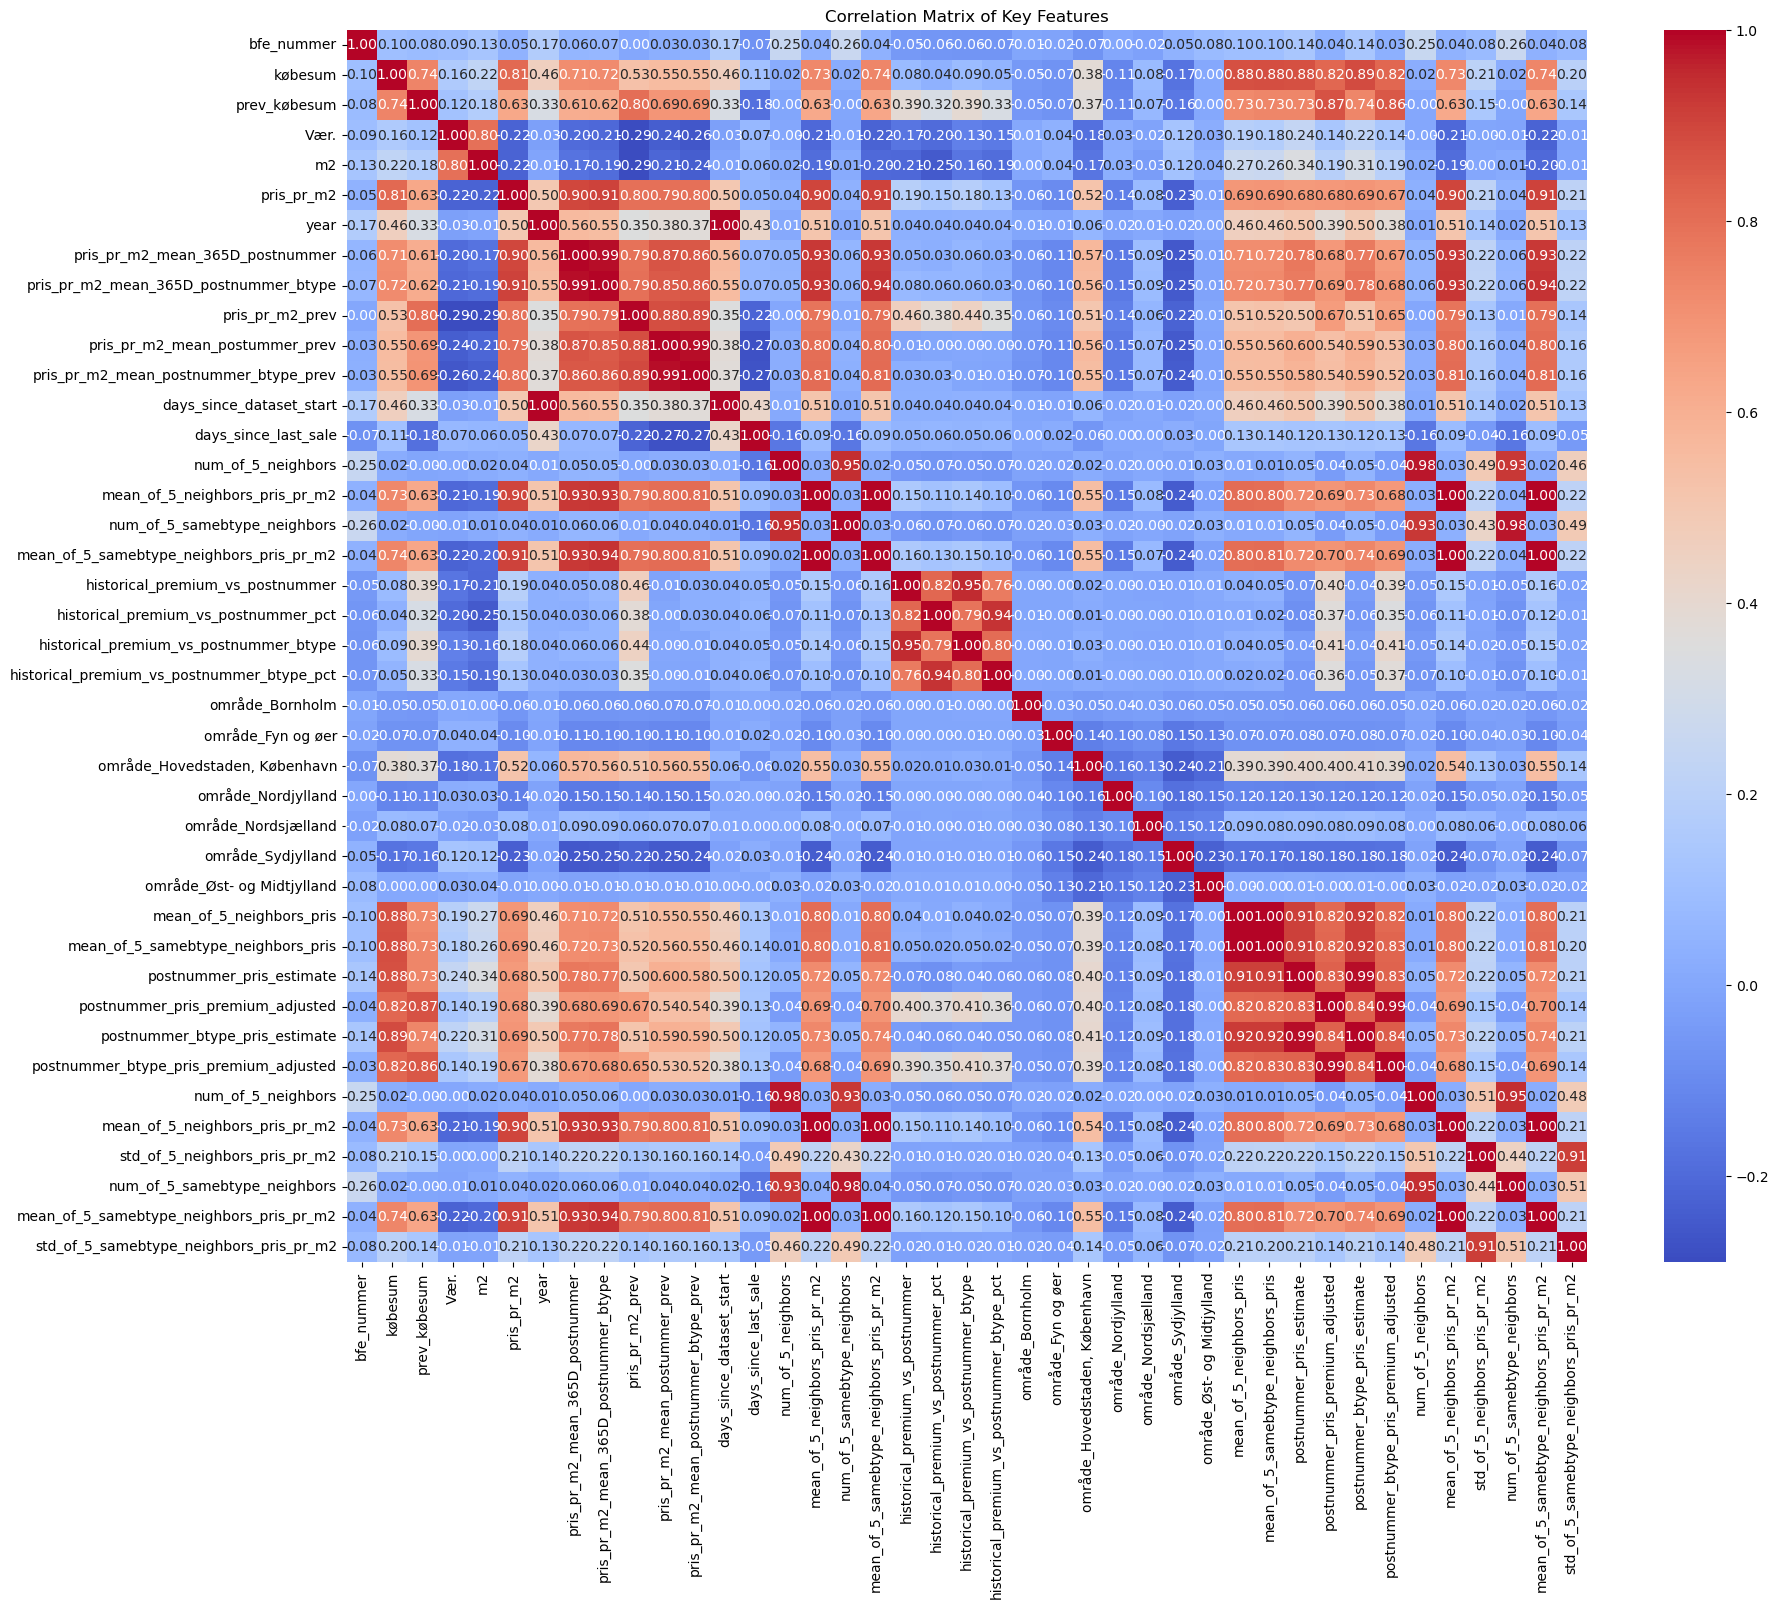

In [42]:
#putting away the bad
correlation_matrix = df_final.drop(columns=['btype', 'x', 'y', 'by','postnummer']).corr()
#correlation_matrix = df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

# honestly i could remove more features but i am going to wait to see what you say

overall mape: 46.8%

By building type:
        btype      mape   count
Ejerlejlighed 23.791571  408046
     Rækkehus 32.301277  172646
        Villa 50.973500 1323849
   Fritidshus 63.122568  280850
  Landejendom 88.850380   43589


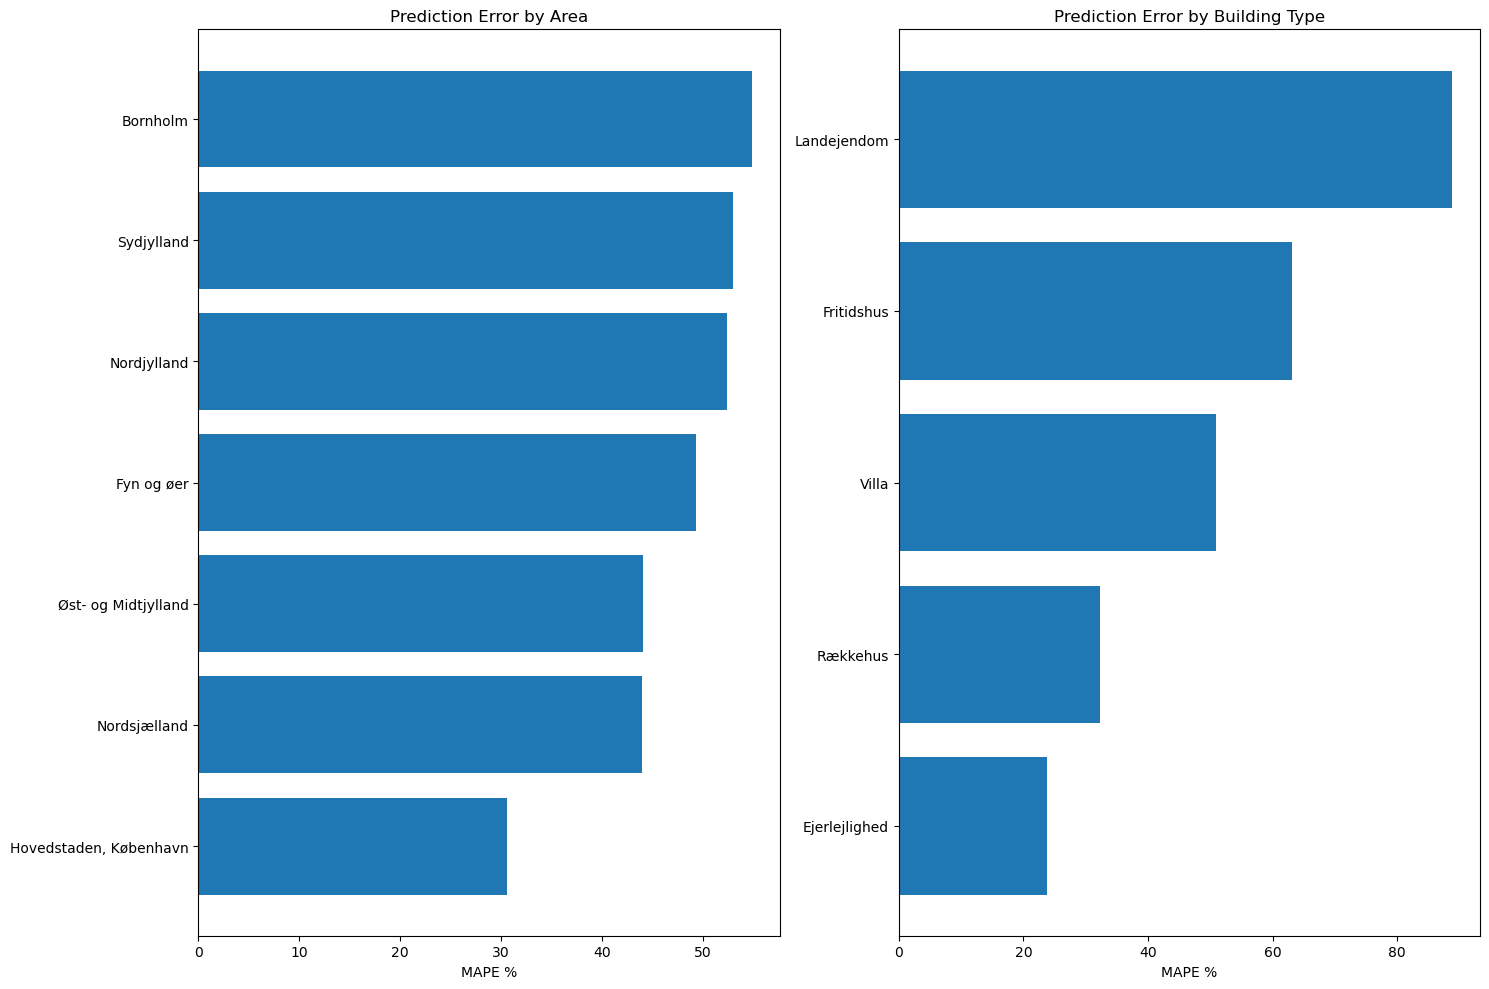


By area:
                  area      mape  count
Hovedstaden, København 30.591680 356520
          Nordsjælland 43.995575 162308
   Øst- og Midtjylland 44.113703 364972
            Fyn og øer 49.300492 187644
           Nordjylland 52.446750 252283
            Sydjylland 52.962342 489881
              Bornholm 54.878439  25815


In [ ]:
df=pd.read_csv("cleaned_data_harshertesttest2.csv")
df

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

actual = df['købesum']
pred = df['mean_of_5_samebtype_neighbors_pris']

# clean up the data
clean_data = df.dropna(subset=['købesum', 'mean_of_5_samebtype_neighbors_pris'])

print(f"overall mape: {mape(clean_data['købesum'], clean_data['mean_of_5_samebtype_neighbors_pris']):.1f}%")

# by area
area_cols = [col for col in clean_data.columns if 'område_' in col]

# quick plot by area
results = []
for col in area_cols:
    area_data = clean_data[clean_data[col] == 1]
    area_name = col.replace('område_', '')
    area_mape = mape(area_data['købesum'], area_data['mean_of_5_samebtype_neighbors_pris'])
    results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Prediction Error by Area')

if 'btype' in clean_data.columns:
    btype_results = []
    for btype in clean_data['btype'].unique():
            btype_data = clean_data[clean_data['btype'] == btype]
            btype_mape = mape(btype_data['købesum'], btype_data['mean_of_5_samebtype_neighbors_pris'])
            btype_results.append([btype, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

overall mape: 48.7%

By building type:
        btype       mape  count
Ejerlejlighed  24.335909 334624
     Rækkehus  30.609140 127447
        Villa  52.997004 954655
   Fritidshus  66.441978 201228
  Landejendom 147.699026  27575


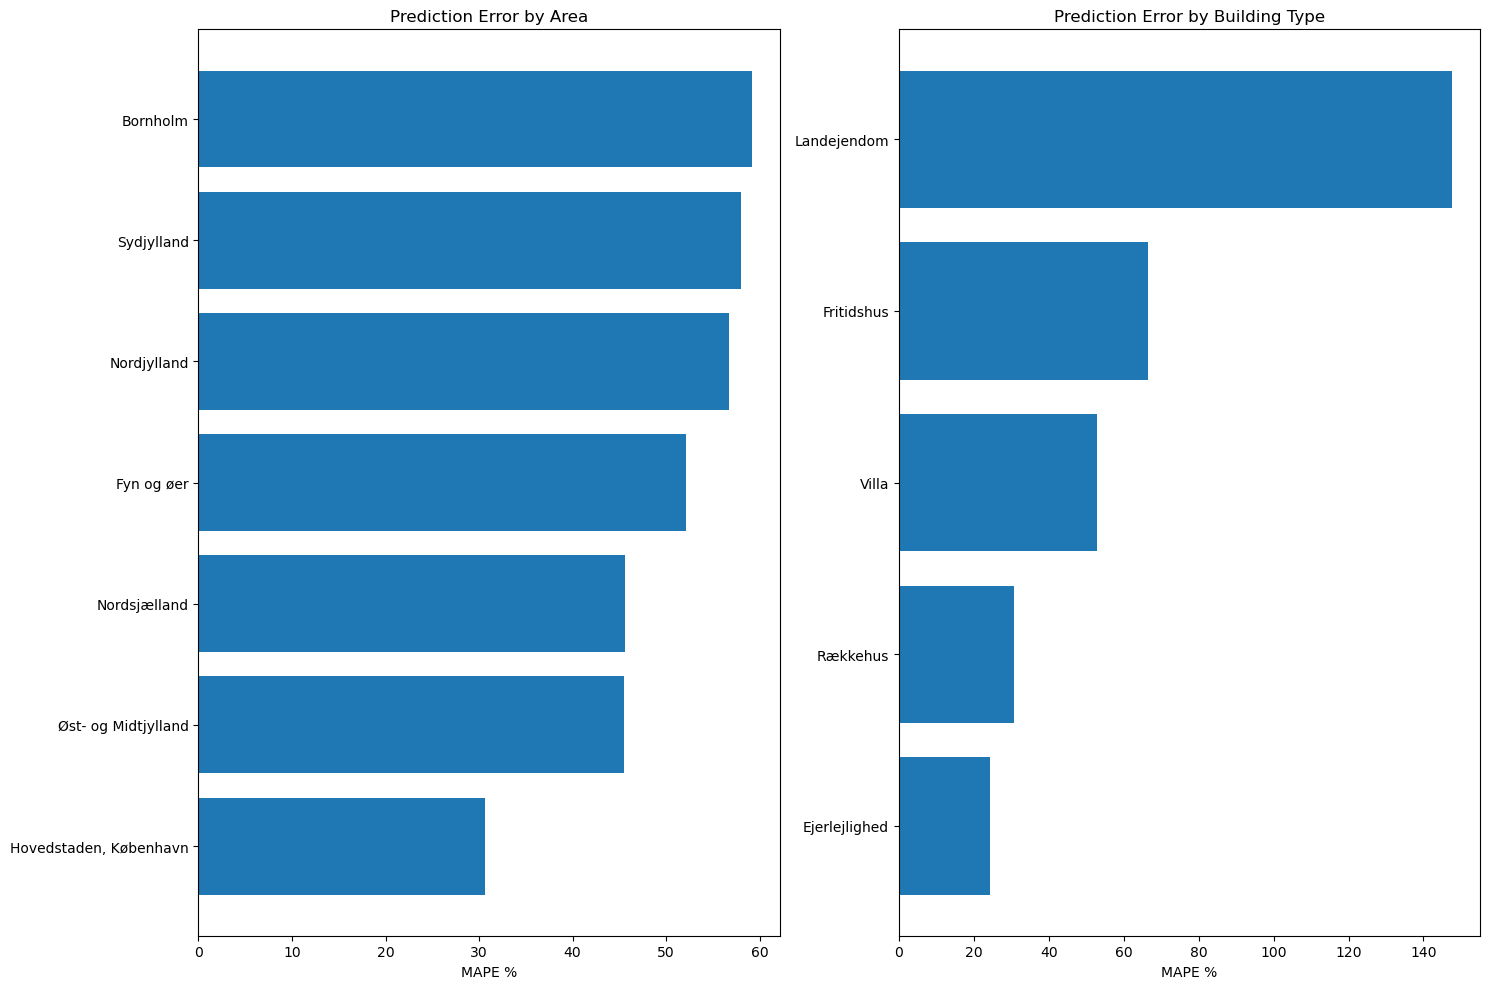


By area:
                  area      mape  count
Hovedstaden, København 30.662048 320117
   Øst- og Midtjylland 45.454177 265978
          Nordsjælland 45.605461 124826
            Fyn og øer 52.122469 128609
           Nordjylland 56.717542 175651
            Sydjylland 57.984958 340260
              Bornholm 59.178972  15926


In [ ]:
df=pd.read_csv("cleaned_data_harshertesttest.csv")
df

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

actual = df['købesum']
pred = df['mean_of_5_samebtype_neighbors_pris']

# clean up the data
clean_data = df.dropna(subset=['købesum', 'mean_of_5_samebtype_neighbors_pris'])

print(f"overall mape: {mape(clean_data['købesum'], clean_data['mean_of_5_samebtype_neighbors_pris']):.1f}%")

# by area
area_cols = [col for col in clean_data.columns if 'område_' in col]

# quick plot by area
results = []
for col in area_cols:
    area_data = clean_data[clean_data[col] == 1]
    area_name = col.replace('område_', '')
    area_mape = mape(area_data['købesum'], area_data['mean_of_5_samebtype_neighbors_pris'])
    results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Prediction Error by Area')

if 'btype' in clean_data.columns:
    btype_results = []
    for btype in clean_data['btype'].unique():
            btype_data = clean_data[clean_data['btype'] == btype]
            btype_mape = mape(btype_data['købesum'], btype_data['mean_of_5_samebtype_neighbors_pris'])
            btype_results.append([btype, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [8]:
# Cell: Add BFE numbers and coordinates back to cleaned data
# Load the original data with BFE and coordinates
df_original = pd.read_csv("with_neighborstesttest.csv")  # This has bfe_nummer, x, y
df_filtered = df_original[
    (df_original['postnummer'] == 2960) & 
    (pd.to_datetime(df_original['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df_original['dato']) <= '2025-08-18')
]
print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

# Get the current cleaned data
df_cleaned = pd.read_csv("cleaned_data_harshertesttest.csv")

print(f"Original data shape: {df_original.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")

# Check if we have a common identifier to merge on
# Look for index or unique identifiers
if 'Unnamed: 0' in df_cleaned.columns and 'Unnamed: 0' in df_original.columns:
    # Merge on the index column
    df_with_bfe_coords = df_cleaned.merge(
        df_original[['Unnamed: 0', 'bfe_nummer', 'x', 'y', 'by', 'postnummer', 'pris_pr_m2']], 
        on='Unnamed: 0', 
        how='left'
    )
elif df_cleaned.index.name == df_original.index.name:
    # Merge on index if they match
    coords_data = df_original[['bfe_nummer', 'x', 'y', 'by', 'postnummer', 'pris_pr_m2']]
    df_with_bfe_coords = pd.concat([df_cleaned, coords_data], axis=1)
else:
    # Try to match by multiple columns (address + date + price)
    # This is more complex but doable if needed
    print("Need to identify matching method...")
    
    # Show what columns we have to work with
    print(f"Cleaned columns: {list(df_cleaned.columns)[:10]}...")
    print(f"Original columns: {list(df_original.columns)[:10]}...")

print(f"Final data with BFE and coords: {df_with_bfe_coords.shape}")
print(f"BFE numbers recovered: {df_with_bfe_coords['bfe_nummer'].notna().sum()}")
print(f"Coordinates recovered: {df_with_bfe_coords['x'].notna().sum()}")

# Filter for postnummer 2960 and date range
df_filtered = df_with_bfe_coords[
    (df_with_bfe_coords['postnummer'] == 2960) & 
    (pd.to_datetime(df_with_bfe_coords['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df_with_bfe_coords['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

# Save the enhanced dataset
df_with_bfe_coords.to_csv("cleaned_data_with_bfe_coords.csv", index=False)
print("✅ Saved as 'cleaned_data_with_bfe_coords.csv'")

# Quick verification
df_with_bfe_coords[['købesum', 'bfe_nummer', 'x', 'y', 'm2', 'by', 'postnummer', 'pris_pr_m2']].head()

Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 8
Original data shape: (2352739, 57)
Cleaned data shape: (2352739, 49)
Final data with BFE and coords: (2352739, 55)
BFE numbers recovered: 2352739
Coordinates recovered: 2352739
Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 8


KeyboardInterrupt: 